# Introduction

**Concept** <br>
Fit a *single GEV distribution* using annual maxima from **pooled data** and compute *stationary GEV analysis* for 
**annually grouped data**.<br>

**Options**
- **Option1**<br>
    pool all data per location for global stationary and non-stationary analysis<br><br>
- **Option2**<br>
    per year grouped data per location for stationary analysis<br>

---
**Workflow Summary (per location)**
1. Extract annual maxima → fit stationary & non-stationary GEV per model
2. Compute return levels & CIs per year per model
3. Compute exceedance probability & CI for thresholds of interest
4. Aggregate multi-model ensemble: mean + total spread
5. Visualization
   1. Return levels vs year (shaded CI)
   2. Probability amplification vs year (shaded CI)
   3. Multi-model ensemble bar plots for future RL
   4. Maps (mean & spread)
6. Tables:
   1. RL per T per year ± CI
   2. Probability change of historical RL


**CHECK** STD Calculation! it is basically 0 and doesnt really make sense 

# Import Packages

In [1]:
from datetime import datetime
from glob import glob
from pathlib import Path
import pickle
import warnings
import random
import matplotlib.pyplot as plt

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

from numpy import arange

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

# Settings

In [2]:
path_input = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/gev_analysis/'

hindcast_start = 1960
hindcast_end = 2026

return_periods = [10, 25, 50, 100, 200]
plot_period_evolution = ['10-year', '50-year', '100-year']
ls_t_eval = 2026, 2050

# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = random.choice(arange(0, 9579))
end_location = start_location+10
print(f'analyse a subsample of location {start_location}–{end_location}')


colors = [
    '#53354DFF','#7D4F73FF','#B887ADFF','#CAA5C2FF','#DBC3D6FF','#F5F5F5FF','#99E3DDFF',
    '#66D4CCFF','#33C6BBFF','#008A80FF','#005C55FF'
    ]

_LOCATION_LABELS = None
export_report=True
display_results = False

analyse a subsample of location 7284–7294


# Import Data

In [ ]:
ls_files = [file for file in glob(path_input + '*.nc')]

print('Importing Data from ...')
print("\n".join(ls_files))

dic_data_per_model = dbf.import_all_models(ls_files)

# Prepare Data

### Pooling, BiasCorrection, ValidityCheck

In [ ]:
print('Pooling and Preparing Data...')
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)
print('... done.')

### Rearrangement to per location

In [ ]:
print('Rearranging Data – sorting per location...')    
dic_data_per_location = dbf.extract_location_data(combined, hindcast_start, hindcast_end)

## Select Subset

In [ ]:
start_location = 1
end_location = 2

if start_location is not None or end_location is not None: 
    dic_data_per_location = ut.select_allowed_locations(
        dic_data_per_location=dic_data_per_location, 
        start_loc=start_location, end_loc=end_location
        )
    print(f'Processing locations {start_location} to {end_location} ({len(dic_data_per_location)} total)')

else:
    print(f'Processing all {len(dic_data_per_location)} locations')

print('Getting closest point available as location label for orientation. \nNote this is not the exact location...')
location_labels = dbf.precompute_location_labels(dic_data_per_location)
location_labels

# (Non-)Stationary GEV Analysis with Pooled Data

When fitting a GEV to annual maxima, there are multiple sources of uncertainty in GEV analysis
- Parameter uncertainty (estimation uncertainty)
- Natural variability / return level uncertainty

**Parameter uncertainty**<br>
The GEV has parameters $(μ, σ, ξ)$ <br>
Each of these parameters is estimated from finite data, so each has an associated uncertainty.
This “uncertainty in the location parameter" can be captured by:
- Parametric sampling: sample $μ ~ Normal(μ, SE_μ)$
- Bootstrap: refit GEV on resampled data
- Delta Method (because the others are too instable)

**Natural variability / return level uncertainty** <br>
Even if parameters were known exactly, extreme values themselves are random.
The return level $z_T$ is defined as a high quantile of the GEV:<br>
$z_T = μ + σ/ξ · [(-ln(1-1/T))^ξ - 1]$
<br>

When sampling from fitted GEV distribution, we can get a confidence interval for $z_T$ given fixed parameters.
This is the *return level uncertainty* captured by `gev_return_levels_ci`.

**Key Differences**
|Concept| How it's captured| Effect|
|---|---|---|
|μ (location) uncertainty	|Parametric bootstrap or μ-sampling from estimated SE	|Adds spread to the estimated parameter itself|
|Return level uncertainty	|Sampling from GEV with fixed parameters	|Adds spread due to natural variability of extremes|
|Combined uncertainty	|Sample μ from its distribution, then compute z_T from each μ	|Gives realistic CIs for return levels, including both sources|


In practice, best approach:
- Sample μ (location) from its uncertainty distribution
- For each μ, compute the return level $z_T$ using the quantile formula
- Compute percentile (median, 95% CI) → includes both parameter uncertainty and natural variability

**EXPECTATION TOWARDS VALUES**<br>
In a stationary Generalized Extreme Value distribution:
- μ(mu) = constant → location parameter
- σ(sigma) = constant → scale parameter
- ξ(xi) = constant → shape parameter<br>

So the distribution does not depend on time.
Therefore, $z_T = f(μ,σ,ξ)$ depends only on T, not on time.

---
**NOTE**
- uncertainty is computed using delta method
- for return levels, the uncertainty in sigma, xi are ignored
- weighted nonstationary STDs >>> tried Fisher, Bootstrap but all unreasonable values... go back to delta method

## Compute for 1 Sample

In [ ]:
def set_location_labels(labels):
    global _LOCATION_LABELS
    _LOCATION_LABELS = labels

In [ ]:
## UPDATE - testing for 1 location | later to be parallelized
# include uncertainty in stationary GEV parameters
uncertainty = 'delta'
B = 300 # bootstrap number - downscaling to 50?! (from 300)
seed = None

# ----------------------------------------------------------------------------------------------------------
results = dict()
loc_id = list(dic_data_per_location.keys())[0]
df_prepared = dic_data_per_location[loc_id]

lon_loc = df_prepared.lon.unique()[0]
lat_loc = df_prepared.lat.unique()[0]

set_location_labels(location_labels)
location_info = _LOCATION_LABELS.get((round(lon_loc,6), round(lat_loc,6)), "unknown location")
print(f'GEV analysis for location {loc_id} · {location_info}')

# ----------------------------------------------------------------------------------------------------------
ls_notes = []
annual_max = gev.extract_annual_maxima_at_location(df_prepared, lon=lon_loc, lat=lat_loc)

if len(annual_max) < 10:
    print('WARNING - not enough data (<10) for location {loc_id} (lon|lat · {lon_loc}|{lat_loc})')

years = annual_max['year'].values
data = annual_max['annual_max'].values

if uncertainty is None:
    uncertainty = "delta"

ls_notes = []
n = len(data)

# ----------------------------------------------------------------------------------------------------------
print("\tConducting (non-)stationary GEV with pooled data...")
pooled_gev, ls_notes = gev.fit_pooled_gev_with_uncertainty(
    loc_id=loc_id, years=years, data=data, uncertainty=uncertainty, trend_params='location', print_msg=True
    )
print(f"\t → (Non-)Stationary GEV done (success {pooled_gev != None})")

print("\tCompare Models...")
comparison = gev.compare_stationary_nonstationary(pooled_gev['stationary'], pooled_gev['nonstationary'], annual_max)

print("\tCompute Return Levels...")
df_all_return_levels = gev.compute_all_return_levels(
    pooled_gev['stationary'], pooled_gev['nonstationary'], return_periods, ls_t_eval
    )
                            
results[loc_id] = dict({
    'location_info': location_info,
    'LatLon': (lat_loc, lon_loc),
    'data':annual_max, 
    'stationary': pooled_gev['stationary'],
    'nonstationary': pooled_gev['nonstationary'],
    'model_comparison': comparison,
    'return_levels': df_all_return_levels
    })

In [ ]:
_ = [gev.print_report(results[loc_ex], loc_ex) for loc_ex in results]

## Plot Figures 

NOTE the result overview refers to the bootstrapped (of Fisher information), hence the (occasional) difference between stationary and non-stationary approach. 

In [ ]:
print(f'Process siteID {loc_id}')

fig = dbplt.plot_pooled_analysis_v2(
    result=results[loc_id], site_id=loc_id, return_periods=return_periods,plot_t_eval=[2026],
    plot_evolution=[int(i.split('-')[0]) for i in plot_period_evolution],
    leg_comparison_x=0.075, leg_comparison_y=0.35, box_parameters_x=0.45,  box_parameters_y= 0.95,
    linestyle_trends = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 10))], fontsize=12, figsize=(15, 7.5),
    display_results=True)


## Store Result(s)

In [ ]:
today_ = str(datetime.today().date().isoformat())   
path_child_folder = Path(path_export) / f"{today_}"

ut.save_pooled_results(results=results, data=None, base_dir=path_child_folder)

In [ ]:
fig_dir = Path(path_child_folder) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

for loc_id, result in results.items():   
    fig = dbplt.plot_pooled_analysis_v2(
        result=result, site_id=loc_id, return_periods=return_periods, plot_t_eval=[2026],
        plot_evolution=[int(i.split('-')[0]) for i in plot_period_evolution],
        leg_comparison_x=0.075, leg_comparison_y=0.35, box_parameters_x=0.45,  box_parameters_y= 0.95,
        linestyle_trends = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 10))], fontsize=12, figsize=(15, 7.5),
        display_results=True
        )

    lat = str(result['LatLon'][0].round(3))
    lon = str(result['LatLon'][1].round(3))
    country = result['location_info'].split(' ')[-1].strip()

    fig.savefig(
        fig_dir / f"location_{loc_id}_{country}_{lat}_{lon}_pooledGEVanalysis.png", 
        dpi=150, bbox_inches="tight"
        )
    plt.close(fig)

# Annual Stationary GEV Analysis

For annual stationary GEV, each yearly fit likely has fewer data samples.
> For a small sample size for a 3-parameter GEV, especially with negative shape, Hessian becomes unstable because:
- Some years will have near-degenerate scale
- Some years will have shape near boundary
- Finite differences step outside parameter support
- Log-likelihood returns inf or nan
- Second derivative formula explodes


> Solution
Compute MLE for annual stationary for 3 parameters and then fit the regression incl uncertainty


**NOTE** in case, run `Import Data` and `Prepare Data` first

In [ ]:
results_all = ut.select_allowed_locations(dic_data_per_location=dic_data_per_location, start_loc=1, end_loc=2)
results_all[1].keys()

In [ ]:
results_annual_stat_all = gev.fit_all_locations(results_all, n_jobs=-1)

In [ ]:
try:
    for loc_id, df_yearly in results_annual_stat_all.items():
        if loc_id in results:
            results[loc_id]['annual_stationary'] = df_yearly
        else:
            results[loc_id] = {'annual_stationary': df_yearly}

except:
    results = {}
    results[loc_id] = dict({'annual_stationary': results_annual_stat_all})

In [ ]:
try:
    dir_export = path_child_folder
except:
    today_ = str(datetime.today().date().isoformat())   
    dir_export = Path(path_export) / f"{today_}"
    
ut.store_annual_stat_results(results_annual_stat_all, dir_export)

# Regression Analysis for Location Parameter μ

- Nonstationary pooled uses already weighting in likelihood > standard regression on fitted mu0/mu1
- Annual stationary needs to actively be included in regression when n_obs vary for years

### Import Data if Needed

In [10]:
dir_import = '../output/gev_analysis/2026-02-27/'

In [11]:
with open(dir_import + 'stationary_per_year.pkl', "rb") as f:
    results_annual_stat_all = pickle.load(f)
    
with open(dir_import + 'nonstationary.pkl', "rb") as f:
    results_nonstat_all = pickle.load(f)
    
with open(dir_import + 'LatLon.pkl', "rb") as f:
    location_geo_info = pickle.load(f)
    
with open(dir_import + 'location_info.pkl', "rb") as f:
    location_point_info = pickle.load(f)

In [15]:
loc_id = list(results_annual_stat_all.keys())[1]
loc_id

2

In [16]:
years_, dic_trend = gev.prepare_for_regression(
    annual_stationary=results_annual_stat_all[loc_id], 
    nonstationary=results_nonstat_all[loc_id],
    years_mean=results_nonstat_all[loc_id]['years_mean'], 
    years_std=results_nonstat_all[loc_id]['years_std'], 
    hindcast_start=hindcast_start, hindcast_end=hindcast_end,
    z_percentile=1.96, factor_m_to_mm=1000
    ) 

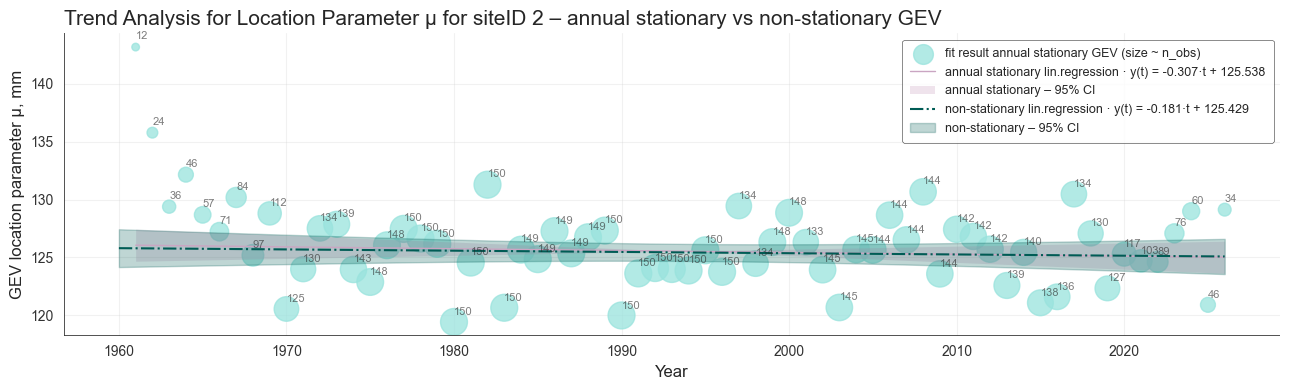

In [17]:
fig_reg = dbplt.plot_location_regression(
    loc_id, years_, dic_trend, results_annual_stat_all[loc_id], 
    axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF',  '#005C55FF'], fontsize=12
    )

## Store regression plot

In [18]:
try:
    dir_export = path_child_folder
except:
    today_ = str(datetime.today().date().isoformat())   
    dir_export = Path(path_export) / f"{today_}"

ut.store_location_regression(fig_reg,loc_id, location_geo_info[loc_id], location_point_info[loc_id], dir_export)

Regression analysis for location parameter stored as ../output/gev_analysis/2026-02-27/figures/location_2_ES_27.696_-18.108_TrendAnalysisLocationParameter.png
